# Determination of Island and Incorporated Locations
* A location is considered incorporated if the EEZ associated with the location is discontinuous from the EEZ associated with the primary land mass of the country.
* A location is an island if it is surrounded by water and at least 250 km from the continental land mass.

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

%matplotlib widget

In [2]:
locations = pd.read_csv("./data/tide_gauge_locations.csv", index_col=0)
locations

,latitude,longitude,station_name,station_country,station_country_code,gloss_id,station_country_alpha3,hdi
uhslc_id,,,,,,,,
1,6.978,158.197,Pohnpei,Micronesia (Federated States of),583,115,FSM,0.614
2,1.332,173.013,"Tarawa, Bairiki",Kiribati,296,113,KIR,0.642
3,-0.437,269.715,Baltra,Ecuador,218,169,ECU,0.773
4,-0.532,166.910,Nauru,Nauru,520,114,NRU,0.700
5,7.107,171.373,Majuro,Marshall Islands (the),584,112,MHL,0.732
...,...,...,...,...,...,...,...,...
913,0.555,97.822,Telukdalam,Indonesia,360,-1,IDN,0.726
914,5.128,96.132,Meulaboh,Indonesia,360,-1,IDN,0.726
915,25.297,60.603,Chabahar,Iran (Islamic Republic of),364,337,IRN,0.793


In [3]:
island_nation_alpha3 = [
    "COK",  # Cook Islands
    "FJI",  # Fiji
    "KIR",  # Kiribati
    "MHL",  # Marshall Islands
    "FSM",  # Micronesia
    "NRU",  # Nauru
    "NZL",  # New Zealand
    "PHL",  # Philippines
    "IDN",  # Indonesia
    "MYS",  # Malaysia
    "PNG",  # Papua New Guinea
    "JPN",  # Japan
    "ISL",  # Iceland
    "WSM",  # Samoa
    "TON",  # Tonga
    "CPV",  # Cape Verde
    "SYC",  # Seychelles
    "MDV",  # Maldives
    "MUS",  # Mauritius
    "PLW",  # Palau
    "SLB",  # Solomon Islands
    "VUT",  # Vanuatu
    "TUV",  # Tuvalu
    "BHS",  # Bahamas
    "LKA",  # Sri Lanka
    "DMA",  # Dominica
    "GRD",  # Grenada
    "DOM",  # Dominican Republic
    "STP",  # São Tomé and Príncipe
    "CUB",  # Cuba
    "JAM",  # Jamaica
    "HTI",  # Haiti
    "MDG",  # Madagascar
    "BRB",  # Barbados
    "TTO",  # Trinidad and Tobago
    "ATG",  # Antigua and Barbuda
]

In [4]:
incorporated = pd.read_csv("./data/incorporated.csv", index_col=0)
incorporated

,station_name,station_country
uhid,,
409,Ofu,American Samoa
408,Tau,American Samoa
407,Aunuu,American Samoa
56,Pago Pago,American Samoa
404,Auasi,American Samoa
...,...,...
832,Rothera,United Kingdom of Great Britain and Northern I...
177,Mawson,Australia
173,Dawson,Australia


In [5]:
discontiguous_islands = pd.read_csv("./data/discontiguous_islands.csv", index_col=0)
discontiguous_islands

,station_name,station_country
uhid,,
409,Ofu,American Samoa
408,Tau,American Samoa
407,Aunuu,American Samoa
56,Pago Pago,American Samoa
404,Auasi,American Samoa
...,...,...
297,Ammassalik,Denmark
299,Qaqortoq,Denmark
820,"Nuuk, Godthaab",Denmark


In [6]:
islands = (
    locations.loc[
        locations.station_country_alpha3.isin(island_nation_alpha3)
        | locations.index.isin(discontiguous_islands.index),
        ["station_name", "station_country"],
    ]
    .copy()
    .sort_values(by="station_country")
)
islands.index.name = "uhid"
islands.to_csv("./data/all_islands.csv")

islands.iloc[:50]

,station_name,station_country
uhid,,
409,Ofu,American Samoa
404,Auasi,American Samoa
56,Pago Pago,American Samoa
407,Aunuu,American Samoa
408,Tau,American Samoa
339,Hobart,Australia
344,Burnie,Australia
62,Norfolk Island,Australia
335,Spring Bay,Australia


In [7]:
locations["island"] = False
locations.loc[islands.index, "island"] = True

locations["incorporated"] = False
locations.loc[incorporated.index, "incorporated"] = True

locations.loc[locations.island].sort_values(by="station_country").iloc[:20]

,latitude,longitude,station_name,station_country,station_country_code,gloss_id,station_country_alpha3,hdi,island,incorporated
uhslc_id,,,,,,,,,,
409,-14.163,190.318,Ofu,American Samoa,16,-1,ASM,0.930,True,True
404,-14.272,189.427,Auasi,American Samoa,16,-1,ASM,0.930,True,True
56,-14.283,189.317,Pago Pago,American Samoa,16,144,ASM,0.930,True,True
407,-14.283,189.438,Aunuu,American Samoa,16,-1,ASM,0.930,True,True
408,-14.240,190.490,Tau,American Samoa,16,-1,ASM,0.930,True,True
339,-42.877,147.342,Hobart,Australia,36,-1,AUS,0.952,True,False
344,-41.050,145.915,Burnie,Australia,36,-1,AUS,0.952,True,False
62,-29.067,167.950,Norfolk Island,Australia,36,124,AUS,0.952,True,True
335,-42.550,147.933,Spring Bay,Australia,36,56,AUS,0.952,True,False


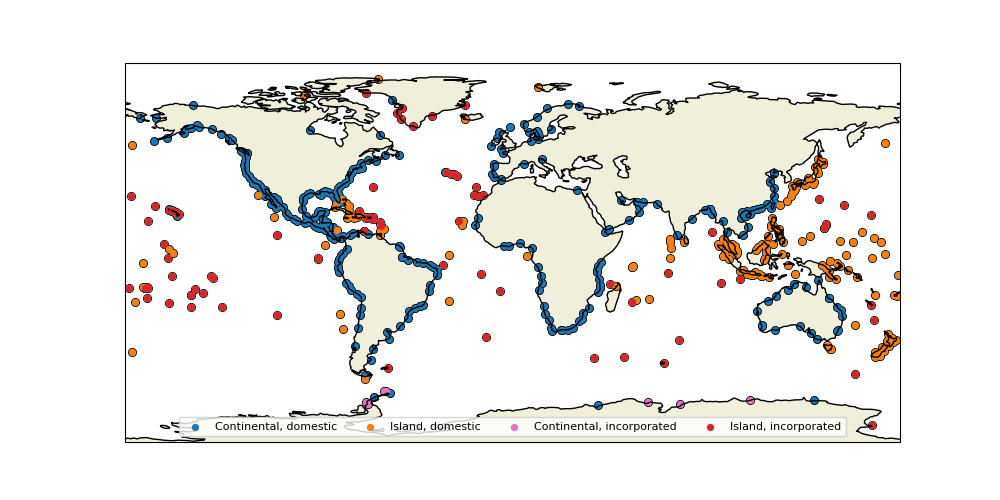

In [8]:
from matplotlib.widgets import Cursor
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a figure and add a map projection
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})

# Add features to the map
ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=":")
# ax.add_feature(cfeature.LAKES, alpha=0.5)
# ax.add_feature(cfeature.RIVERS)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Plot the locations
_ = ax.scatter(
    locations["longitude"],
    locations["latitude"],
    color="k",
    s=30,
    alpha=1,
    transform=ccrs.PlateCarree(),
    label="",
)
sc = ax.scatter(
    locations["longitude"],
    locations["latitude"],
    color=colors[0],
    s=18,
    alpha=1,
    transform=ccrs.PlateCarree(),
    label="Continental, domestic",
)
isl = locations[locations.island]
_ = ax.scatter(
    isl["longitude"],
    isl["latitude"],
    color=colors[1],
    s=18,
    alpha=1,
    transform=ccrs.PlateCarree(),
    label="Island, domestic",
)
isl_col = locations[locations.incorporated]
_ = ax.scatter(
    isl_col["longitude"],
    isl_col["latitude"],
    color=colors[6],
    # edgecolor="k",
    s=18,
    alpha=1,
    transform=ccrs.PlateCarree(),
    label="Continental, incorporated",
)
isl_col = locations[locations.island & locations.incorporated]
_ = ax.scatter(
    isl_col["longitude"],
    isl_col["latitude"],
    color=colors[3],
    # edgecolor="k",
    s=18,
    alpha=1,
    transform=ccrs.PlateCarree(),
    label="Island, incorporated",
)

plt.legend(loc="lower center", ncol=4, fontsize=8)

# Add a cursor for hovering
# cursor = Cursor(ax, useblit=True, color="red", linewidth=1)

# Function to update annotation
annot = ax.annotate(
    "",
    xy=(0, 0),
    xytext=(20, 20),
    textcoords="offset points",
    bbox=dict(boxstyle="round", fc="w"),
    arrowprops=dict(arrowstyle="->"),
)
annot.set_visible(False)


def update_annot(ind):
    pos = sc.get_offsets()[ind["ind"][0]]
    annot.xy = pos
    uhslc_id = locations.index[ind["ind"][0]]
    text = f"UHSLC ID: {uhslc_id}\nName: {locations.iloc[ind['ind'][0]]['station_name']}\nCountry: {locations.iloc[ind['ind'][0]]['station_country']}\nHDI: {locations.iloc[ind['ind'][0]]['hdi']}\nIsland: {locations.iloc[ind['ind'][0]]['island']}\nincorporated: {locations.iloc[ind['ind'][0]]['incorporated']}"
    annot.set_text(text)
    annot.get_bbox_patch().set_alpha(1)


def print_station_info(ind):
    uhslc_id = locations.index[ind["ind"][0]]
    station_name = locations.iloc[ind["ind"][0]]["station_name"]
    station_name = f'"{station_name}"' if "," in station_name else station_name
    station_country = locations.iloc[ind["ind"][0]]["station_country"]
    station_country = (
        f'"{station_country}"' if "," in station_country else station_country
    )
    print(" " * 100, end="\r")
    print(f"{uhslc_id},{station_name},{station_country}", end="\r")


def hover(event):
    vis = annot.get_visible()
    if event.inaxes == ax:
        if event.button == 1:  # Left mouse button
            cont, ind = sc.contains(event)
            if cont:
                update_annot(ind)
                annot.set_visible(True)
                fig.canvas.draw_idle()
                print_station_info(ind)
            else:
                if vis:
                    annot.set_visible(False)
                    fig.canvas.draw_idle()


# def hover(event):
#     vis = annot.get_visible()
#     if event.inaxes == ax:
#         if event.button == 1:  # Left mouse button
#             cont, ind = sc.contains(event)
#             if cont:
#                 update_annot(ind)
#                 annot.set_visible(True)
#                 fig.canvas.draw_idle()
#             else:
#                 if vis:
#                     annot.set_visible(False)
#                     fig.canvas.draw_idle()


fig.canvas.mpl_connect("button_press_event", hover)

plt.show()

In [9]:
def haversine_by_id(id1, id2):
    """
    Calculate the great circle distance in kilometers between two stations given their uhslc_id,
    using the locations dataframe.
    """
    from math import radians, sin, cos, sqrt, atan2

    lat1 = locations.loc[id1, "latitude"]
    lon1 = locations.loc[id1, "longitude"]
    lat2 = locations.loc[id2, "latitude"]
    lon2 = locations.loc[id2, "longitude"]

    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    r = 6371.0  # Radius of earth in kilometers
    return c * r


haversine_by_id(36, 308)

285.91049407070847